# P7 — Thematic Alignment in Scientific Journals

## **Considered Journal:**
## *Ecological Economics* (ISSN 0921-8009)

Sofya Strelskaya (47912A)  
Data Science for Economics

---
All core logic lives in three classes:
1. `CorpusLoader`: `src.data.loader` (load and validate corpus + scope text)
2. `CorpusEmbedder`: `src.models.embedder` (embed text with Sentence-BERT)
3. `AlignmentScorer`: `src.models.scorer` (score, detect outliers, compute drift |

---
## 0. Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# adding project root to path, so that src/ is importable
sys.path.insert(0, str(Path('../').resolve()))

# project modules
from src.data.loader import CorpusLoader
from src.models.embedder import CorpusEmbedder
from src.models.scorer import AlignmentScorer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All imports OK.')
print(f'CorpusLoader: {CorpusLoader}')
print(f'CorpusEmbedder: {CorpusEmbedder}')
print(f'AlignmentScorer: {AlignmentScorer}')

/Users/sofyastrelskaya/Desktop/ecological-economics-alignment/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.
CorpusLoader   : <class 'src.data.loader.CorpusLoader'>
CorpusEmbedder : <class 'src.models.embedder.CorpusEmbedder'>
AlignmentScorer: <class 'src.models.scorer.AlignmentScorer'>


---
## 1. Load the Corpus

Using `CorpusLoader` to load the paper corpus and the Aims & Scope text.

In [2]:
loader = CorpusLoader(
    papers_path='../data/raw/papers.jsonl',
    scope_path ='../data/aims_scope.txt',)

df = loader.load_papers()
scope_text = loader.load_scope()

print(f'Corpus shape : {df.shape}')
print(f'Years: {df["year"].min()} - {df["year"].max()}')
print(f'Scope length: {len(scope_text)} characters')
df.head(3)

Corpus shape : (2121, 6)
Years        : 2014 - 2024
Scope length : 1865 characters


,title,doi,date,year,abstract,abstract_len
0,Present bias predicts participation in payment...,10.1016/j.ecolecon.2014.07.026,2014-12-01,2014,Farmers are necessary agents in global efforts...,1351
1,Socio-cultural valuation of ecosystem services...,10.1016/j.ecolecon.2014.09.028,2014-12-01,2014,Ecosystem services studies currently lack info...,1525
2,"Environmental protection goals, policy & publi...",10.1016/j.ecolecon.2014.09.025,2014-12-01,2014,One of the most divisive debates in modern agr...,1296


### 1.1 Corpus Overview

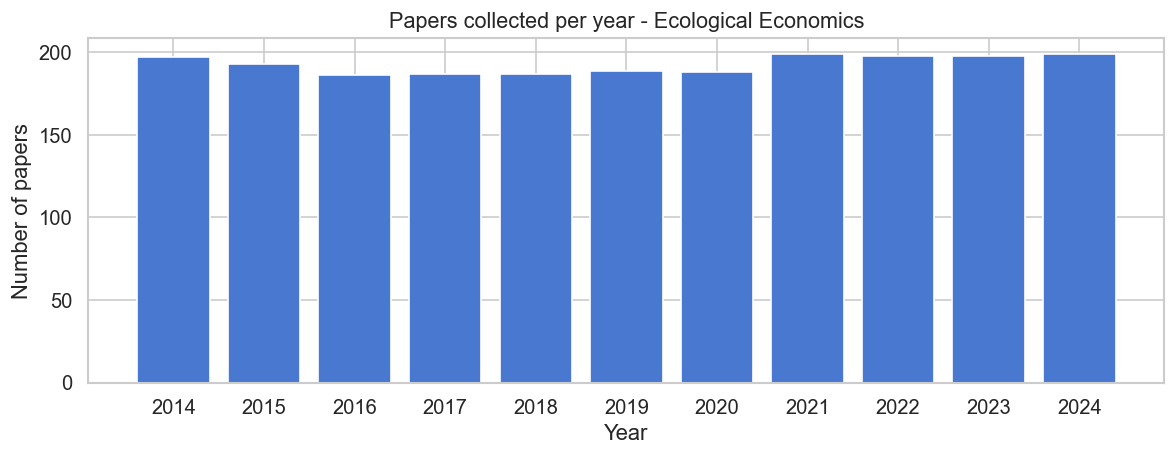

 year  count
 2014    197
 2015    193
 2016    186
 2017    187
 2018    187
 2019    189
 2020    188
 2021    199
 2022    198
 2023    198
 2024    199
Total: 2121 papers | Median abstract: 1292 chars


In [3]:
papers_per_year = df.groupby('year').size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(papers_per_year['year'], papers_per_year['count'],
       color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_title('Papers collected per year - Ecological Economics', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of papers')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('../data/fig_corpus_overview.png', dpi=150)
plt.show()
print(papers_per_year.to_string(index=False))
print(f'Total: {len(df)} papers | Median abstract: {df["abstract_len"].median():.0f} chars')

---
## 2. Aims & Scope

The journal's Aims & Scope statement serves as the baseline: the official description of what the journal is supposed to publish. This text is embedded into the same vector space as the abstracts, so the distance between them can be measured.

To be noted that only the thematic paragraphs (not the submission guidelines section) are used to keep the reference vector focused on content rather than process.

In [4]:
print(f'Aims & Scope ({len(scope_text)} characters):\n')
print(scope_text)

Aims & Scope (1865 characters):

The Transdisciplinary Journal of the International Society for Ecological Economics (ISEE)

The journal is concerned with extending and integrating the understanding of the interfaces and interplay between "nature's household" (ecosystems) and "humanity's household" (the economy). Ecological economics is an interdisciplinary field defined by a set of concrete problems or challenges related to governing economic activity in a way that promotes human well-being, sustainability, and justice. The journal thus emphasizes critical work that draws on and integrates elements of ecological science, economics, and the analysis of values, behaviors, cultural practices, institutional structures, and societal dynamics. The journal is transdisciplinary in spirit and methodologically open, drawing on the insights offered by a variety of intellectual traditions, and appealing to a diverse readership.

Specific research areas covered include: valuation of natural resour

---
## 3. Text Embeddings

`CorpusEmbedder` wraps Sentence-BERT with automatic caching. First run computes and saves vectors. Subsequent runs load from cache.

A few notes: The Sentence-BERT is used because unlike word embeddings (Word2Vec) that represent individual words, it produces a single vector for an entire sentence or paragraph, preserving context and meaning across the full text. Thus, it is suitable for comapring documents thematically rather than lexically.

Another thing is that `all-MiniLM-L6-v2` is used because it is fast, memory-efficient, and performs well on semantics similarity tasks, which is a good balance between quality and computational costs for a corpus of ~2000 abstracts on my laptop. The previous one crashed the kernel)

In [28]:
embedder = CorpusEmbedder(
    model_name='all-MiniLM-L6-v2',
    cache_dir='../data',)

abstracts = df['abstract'].tolist()
abstract_vecs = embedder.embed_corpus(abstracts)
scope_vec = embedder.embed_scope(scope_text)

print(f'Abstract matrix shape: {abstract_vecs.shape}')
print(f'Scope vector shape: {scope_vec.shape}')
print(f'Vectors normalised: {np.allclose(np.linalg.norm(abstract_vecs, axis=1), 1.0)}')

Abstract matrix shape: (2121, 384)
Scope vector shape: (384,)
Vectors normalised: True


---
## 4. Alignment Scores

`AlignmentScorer.score()` computes cosine similarity between each abstract vector and the scope vector. Score being close to 1 means that the paper's content is very close to the journal's stated focus. Score close to 0 means that the paper reads a thematically distant from the stated scope.

In [9]:
scorer = AlignmentScorer(std_threshold=1.5, top_n=10)

df = scorer.score(df, abstract_vecs, scope_vec)
df = scorer.flag_editorial(df)

print('Alignment score summary:')
print(df['alignment_score'].describe().round(4))
print(f'\nEditorial entries flagged: {df["is_editorial"].sum()}')

df_research = df[~df['is_editorial']].copy()
print(f'Research papers: {len(df_research)}')

Alignment score summary:
count    2121.0000
mean        0.3498
std         0.1018
min         0.0057
25%         0.2808
50%         0.3467
75%         0.4132
max         0.7213
Name: alignment_score, dtype: float64

Editorial entries flagged: 16
Research papers          : 2105


In [29]:
# Sanity check (manually verifying 3 papers: max, min, random middle paper)
for idx in [df['alignment_score'].idxmax(), df['alignment_score'].idxmin(), df.index[len(df)//2]]:
    row = df.iloc[idx]
    print(f'{'='*65}')
    print(f'Score: {row["alignment_score"]:.4f}')
    print(f'Title: {row["title"]}')
    print(f'Abstract: {row["abstract"][:200]}...')

Score: 0.7213
Title: Why ecological economics needs to return to its roots: The biophysical foundation of socio-economic systems
Abstract: Ecological economics was formally established in 1989 with the ambitious vision of developing a new economic paradigm embedding the social and economic systems in the biophysical world. Ecological eco...
Score: 0.0057
Title: Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Case of Climate Change (Ecological Economics (2020) 175, (S0921800919315319), (10.1016/j.ecolecon.2020.106696))
Abstract: The authors regret two reporting errors (wrong signs) in Table A2. The correct coefficient of the regression of Care with respect to Left-Right Scale is −0.02: The correct coefficient of the regressio...
Score: 0.6020
Title: On the Circular Bioeconomy and Decoupling: Implications for Sustainable Growth
Abstract: This paper explores the existing confusion around the conceptual definitions and interpretations of the term circular bioecono

In [30]:
# Second lowest scoring paper
second_min = df.nsmallest(2, "alignment_score").iloc[1]
print(f"Score: {second_min['alignment_score']:.4f}")
print(f"Title: {second_min['title']}")
print(f"Year: {second_min['year']}")
print(f"\nAbstract:\n{second_min['abstract']}")

Score: 0.0288
Title: The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized Controlled Experiment
Year: 2018

Abstract:
Improving farmers’ knowledge of fertilizer use through agricultural training has been considered a prerequisite to scientific fertilizer management. However, empirical evidence of the effect of agricultural training on farmers’ fertilizer management knowledge is inconclusive. Based on a randomized controlled experiment involving 687 farmers that mitigates selection bias in the data, this paper identifies the treatment effect of agricultural training on farmers’ fertilizer management knowledge in Chinese rice production. Results indicate that the fertilizer management knowledge of field-guidance farmers improved by almost 40%. However, such knowledge acquisition did not occur for curriculum-trained farmers. We also find that there is no evidence of knowledge diffusion from trained farmers to exposed farmers in the same village.


### 4.1 Score Distribution

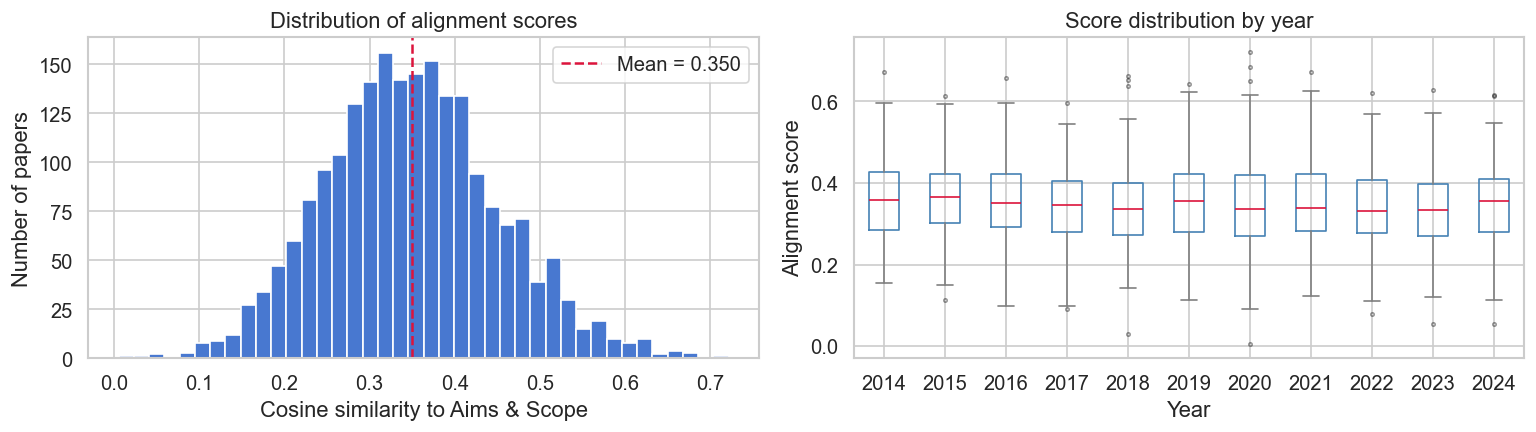

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['alignment_score'], bins=40, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].axvline(df['alignment_score'].mean(), color='crimson', linestyle='--',
                label=f'Mean = {df["alignment_score"].mean():.3f}')
axes[0].set_title('Distribution of alignment scores')
axes[0].set_xlabel('Cosine similarity to Aims & Scope')
axes[0].set_ylabel('Number of papers')
axes[0].legend()
df.boxplot(column='alignment_score', by='year', ax=axes[1],
           color=dict(boxes='steelblue', whiskers='gray', medians='crimson', caps='gray'),
           flierprops=dict(marker='o', markersize=2, alpha=0.4))
axes[1].set_title('Score distribution by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Alignment score')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/fig_score_distribution.png', dpi=150)
plt.show()

---
## 5. Thematic Drift Over Time

`AlignmentScorer.drift_by_year()` aggregates scores by year with 95% confidence intervals.

In [12]:
yearly = scorer.drift_by_year(df)
print(yearly.round(4).to_string(index=False))

 year   mean    std  median  count   ci95
 2014 0.3615 0.1040  0.3579    197 0.0145
 2015 0.3691 0.1019  0.3649    193 0.0144
 2016 0.3537 0.0971  0.3515    186 0.0140
 2017 0.3436 0.0922  0.3472    187 0.0132
 2018 0.3397 0.0966  0.3361    187 0.0138
 2019 0.3595 0.1033  0.3560    189 0.0147
 2020 0.3501 0.1186  0.3366    188 0.0170
 2021 0.3515 0.1065  0.3378    199 0.0148
 2022 0.3365 0.1001  0.3313    198 0.0139
 2023 0.3347 0.0963  0.3347    198 0.0134
 2024 0.3479 0.0980  0.3553    199 0.0136


In [13]:
period_stats = scorer.period_comparison(df_research, split_year=2018)
print(period_stats)

          mean     std  count
period                       
>2018   0.3480  0.1031   1160
≤2018   0.3542  0.0986    945


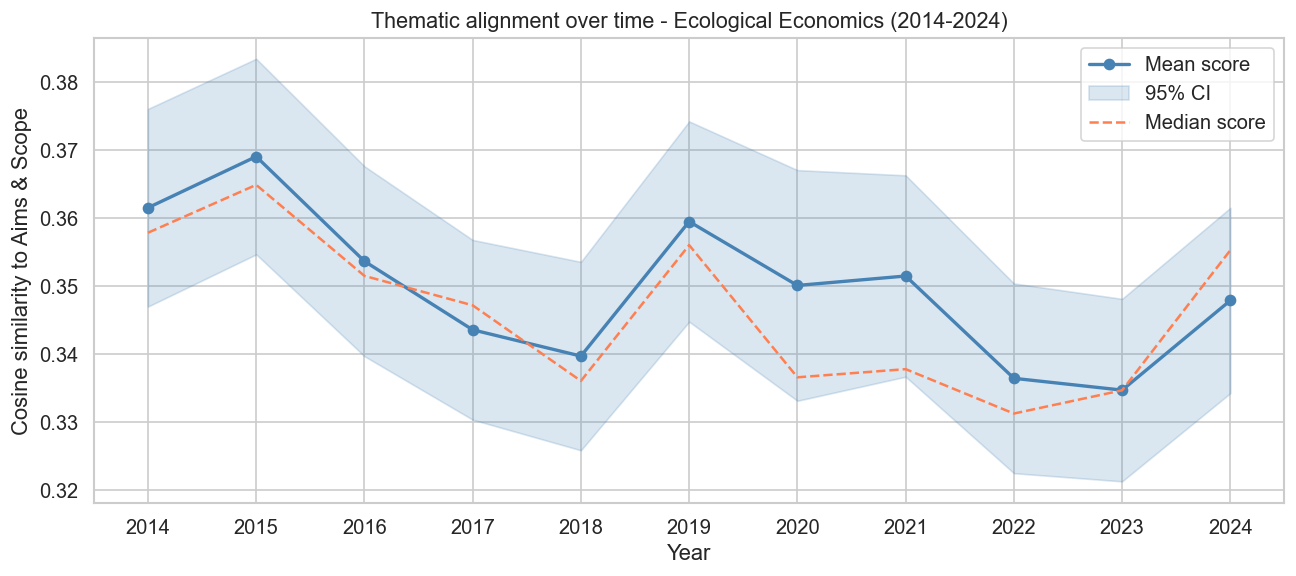

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly['year'], yearly['mean'], marker='o', color='steelblue', linewidth=2, label='Mean score')
ax.fill_between(yearly['year'], yearly['mean'] - yearly['ci95'], yearly['mean'] + yearly['ci95'],
                alpha=0.2, color='steelblue', label='95% CI')
ax.plot(yearly['year'], yearly['median'], linestyle='--', color='coral', linewidth=1.5, label='Median score')
ax.set_title('Thematic alignment over time - Ecological Economics (2014-2024)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Cosine similarity to Aims & Scope')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.savefig('../data/fig_drift.png', dpi=150)
plt.show()

---
## 6. Outlier Detection

`AlignmentScorer.outlier_report()` identifies papers more than 1.5 std below the mean (papers that are unusually far from the journal's stated scope)

In [15]:
report = scorer.outlier_report(df)
print(report)
print(f'Threshold: {report.threshold:.4f}')
print(f'Outliers: {report.n_outliers} ({report.outlier_pct:.1f}% of corpus)')

OutlierReport — threshold: 0.1970 | outliers: 130 (6.1%)
Threshold : 0.1970
Outliers  : 130 (6.1% of corpus)


### 6.1 Most & Least aligned papers (top 10)

In [16]:
cols = ['year', 'alignment_score', 'title', 'doi']
pd.set_option('display.max_colwidth', 80)
print('TOP 10 most aligned:')
display(report.top_papers[cols].reset_index(drop=True))
print('\nBOTTOM outliers:')
display(report.outliers[cols].head(10).reset_index(drop=True))

TOP 10 most aligned:


,year,alignment_score,title,doi
0,2020,0.721281,Why ecological economics needs to return to its roots: The biophysical found...,10.1016/j.ecolecon.2019.106567
1,2020,0.684162,Between Ostrom and Nordhaus: The research landscape of sustainability economics,10.1016/j.ecolecon.2020.106620
2,2021,0.672815,"Integrating the green economy, circular economy and bioeconomy in a strategi...",10.1016/j.ecolecon.2021.107143
3,2014,0.671550,The second generation of ecological economics: How far has the apple fallen ...,10.1016/j.ecolecon.2014.09.020
4,2018,0.661205,Searching for a Scientific Paradigm in Ecological Economics: The History of ...,10.1016/j.ecolecon.2018.07.022
5,2016,0.657068,Influential publications in ecological economics revisited,10.1016/j.ecolecon.2016.01.007
6,2018,0.651745,Mainstream economics toolkit within the ecological economics framework,10.1016/j.ecolecon.2017.10.024
7,2020,0.649940,The Ecological Economics of Economic Democracy,10.1016/j.ecolecon.2020.106750
8,2019,0.642986,Avoiding dualisms in ecological economics: Towards a dialectically-informed ...,10.1016/j.ecolecon.2019.05.004
9,2018,0.637676,Re-establishing Justice as a Pillar of Ecological Economics Through Feminist...,10.1016/j.ecolecon.2018.05.022



BOTTOM outliers:


,year,alignment_score,title,doi
0,2020,0.005689,Corrigendum to Moral Foundations and Voluntary Public Good Provision: The Ca...,10.1016/j.ecolecon.2020.106786
1,2018,0.028818,The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized ...,10.1016/j.ecolecon.2018.02.004
2,2023,0.053233,Can market segmentation improve the performance of water quality trading auc...,10.1016/j.ecolecon.2023.107934
3,2024,0.053520,Fighting crime to improve recycling: Evaluating an anti-mafia policy on sour...,10.1016/j.ecolecon.2024.108291
4,2022,0.078062,Particulate matter and COVID-19 excess deaths: Decomposing long-term exposur...,10.1016/j.ecolecon.2022.107340
5,2017,0.090783,Can Personality Traits Explain Where and With Whom You Recreate? A Latent-Cl...,10.1016/j.ecolecon.2017.03.038
6,2020,0.091369,"Flying More Efficiently: Joint Impacts of Fuel Prices, Capital Costs and Fle...",10.1016/j.ecolecon.2020.106714
7,2016,0.097701,Gains from investments in snowmaking facilities,10.1016/j.ecolecon.2016.08.003
8,2017,0.099129,Stability of Willingness-to-Pay for Coastal Management: A Choice Experiment ...,10.1016/j.ecolecon.2017.03.031
9,2020,0.099832,"Biotech Crops, Input Use and Landslides Case Study of Herbicide Tolerant Cor...",10.1016/j.ecolecon.2020.106773


In [31]:
# taking the single lowest scoring paper from the outliers and filtering out the editorial content 
research_outliers = report.outliers[~report.outliers['is_editorial']]
worst = research_outliers.iloc[0]
print(f'Title: {worst["title"]}')
print(f'Year: {worst["year"]}')
print(f'Score: {worst["alignment_score"]:.4f}')
print(f'\nAbstract:\n{worst["abstract"]}')

Title: The Role of Agricultural Training on Fertilizer Use Knowledge: A Randomized Controlled Experiment
Year: 2018
Score: 0.0288

Abstract:
Improving farmers’ knowledge of fertilizer use through agricultural training has been considered a prerequisite to scientific fertilizer management. However, empirical evidence of the effect of agricultural training on farmers’ fertilizer management knowledge is inconclusive. Based on a randomized controlled experiment involving 687 farmers that mitigates selection bias in the data, this paper identifies the treatment effect of agricultural training on farmers’ fertilizer management knowledge in Chinese rice production. Results indicate that the fertilizer management knowledge of field-guidance farmers improved by almost 40%. However, such knowledge acquisition did not occur for curriculum-trained farmers. We also find that there is no evidence of knowledge diffusion from trained farmers to exposed farmers in the same village.


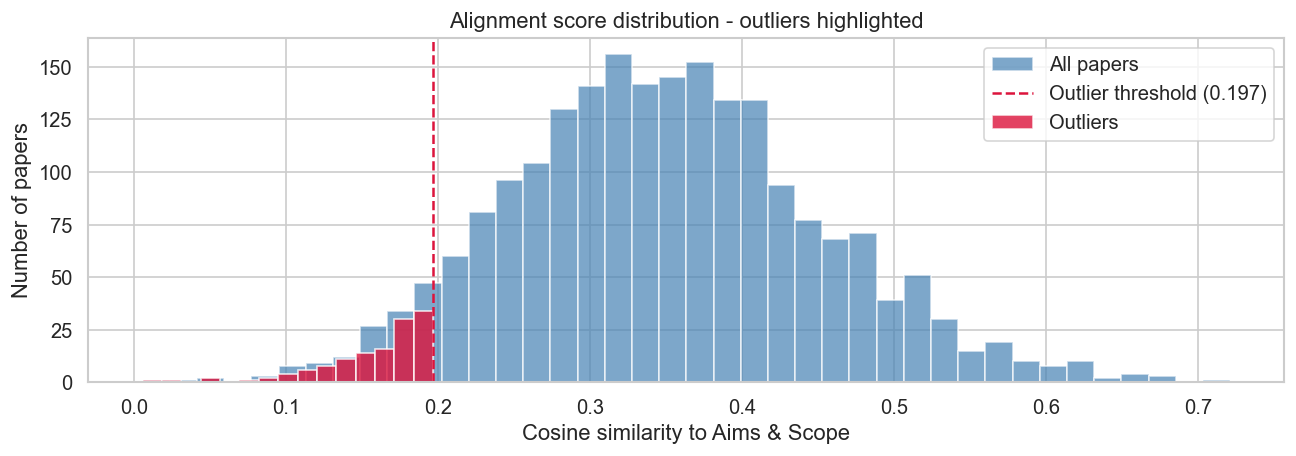

In [18]:
# visualising outliers on the score distribution
outliers = report.outliers
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(df['alignment_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='All papers')
ax.axvline(report.threshold, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Outlier threshold ({report.threshold:.3f})')
ax.hist(outliers['alignment_score'], bins=15, color='crimson', edgecolor='white', alpha=0.8, label='Outliers')
ax.set_title('Alignment score distribution - outliers highlighted')
ax.set_xlabel('Cosine similarity to Aims & Scope')
ax.set_ylabel('Number of papers')
ax.legend()
plt.tight_layout()
plt.savefig('../data/fig_outliers.png', dpi=150)
plt.show()

In [32]:
# categorising outliers into meanigful groups
def categorise_outlier(title, abstract):
    text = (title + ' ' + abstract).lower()
    if any(w in text for w in ['corrigendum', 'erratum', 'correction to']): return 'Editorial correction'
    elif any(w in text for w in ['fertilizer', 'crop', 'farming', 'farmer', 'soil']): return 'Pure agronomy'
    elif any(w in text for w in ['covid', 'particulate matter', 'mortality', 'epidemi']): return 'Public health / epidemiology'
    elif any(w in text for w in ['mafia', 'crime', 'criminal', 'fraud']): return 'Criminology'
    elif any(w in text for w in ['gdp growth', 'exponential growth', 'macroeconomic']): return 'Pure macroeconomics'
    elif any(w in text for w in ['aircraft', 'aviation', 'airline']): return 'Transport engineering'
    else: return 'Other / peripheral'

outliers = outliers.copy()
outliers['category'] = outliers.apply(lambda r: categorise_outlier(r['title'], r['abstract']), axis=1)
category_counts = outliers['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
print(category_counts.to_string(index=False))

                    category  count
          Other / peripheral     92
               Pure agronomy     14
        Editorial correction     10
Public health / epidemiology      6
                 Criminology      4
       Transport engineering      2
         Pure macroeconomics      2


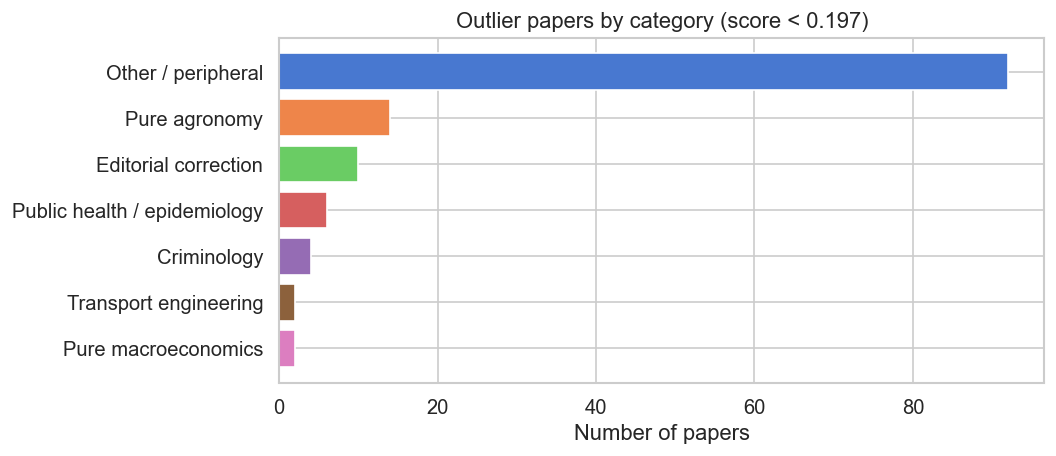

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(category_counts['category'], category_counts['count'],
        color=sns.color_palette('muted', len(category_counts)), edgecolor='white')
ax.set_title(f'Outlier papers by category (score < {report.threshold:.3f})')
ax.set_xlabel('Number of papers')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/fig_outlier_categories.png', dpi=150)
plt.show()

---
## 7. Topic Modelling with BERTopic

BERTopic identifies latent themes across the corpus by clustering documents in embedding space and extracting representative keywords for each cluster using a class-based TF-IDF procedure (Grootendorst, 2022).

This allows to:
1. see what themes the journal actually publishes
2. cross-tabulate topics with alignment scores (which themes score highest/lowest)
3. track which topics grew or shrank over time

In [34]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))

topic_model = BERTopic(
    umap_model=umap_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer,
    language='english', calculate_probabilities=False, verbose=True, nr_topics='auto',
)

print('Fitting BERTopic...')
topics, _ = topic_model.fit_transform(abstracts, abstract_vecs)
df['topic'] = topics
print(f'Topics found: {len(set(topics)) - 1}')
topic_model.get_topic_info().head(15)

2026-05-15 15:59:30,880 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic...


2026-05-15 15:59:34,907 - BERTopic - Dimensionality - Completed ✓
2026-05-15 15:59:34,908 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-15 15:59:34,935 - BERTopic - Cluster - Completed ✓
2026-05-15 15:59:34,936 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-15 15:59:35,387 - BERTopic - Representation - Completed ✓
2026-05-15 15:59:35,388 - BERTopic - Topic reduction - Reducing number of topics
2026-05-15 15:59:35,392 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-15 15:59:35,819 - BERTopic - Representation - Completed ✓
2026-05-15 15:59:35,821 - BERTopic - Topic reduction - Reduced number of topics from 43 to 17


Topics found: 16


,Topic,Count,Name,Representation,Representative_Docs
0,-1,766,-1_environmental_economic_results_policy,"[environmental, economic, results, policy, study, model, energy, paper, use,...","[Deforestation is a major environmental issue in developing countries, and a..."
1,0,993,0_environmental_economic_results_social,"[environmental, economic, results, social, paper, carbon, ecosystem, climate...",[Ecologists and economists have promoted the concept of ecosystem services a...
2,1,62,1_fishing_fisheries_fishery_fish,"[fishing, fisheries, fishery, fish, fishers, economic, model, bioeconomic, s...",[This paper deals with fishery management in the face of the ecological and ...
3,2,37,2_environmental_regulation_firms_innovation,"[environmental, regulation, firms, innovation, environmental regulation, pol...",[Whether environmental regulation incentivizes green technology innovations ...
4,3,34,3_water_virtual_virtual water_agricultural,"[water, virtual, virtual water, agricultural, water resources, economic, pro...",[Water is an important factor of production contributing both directly and i...
5,4,31,4_water_water quality_quality_trading,"[water, water quality, quality, trading, nutrient, quality trading, lake, co...",[Improving water quality and other ecosystem services in agriculturally domi...
6,5,28,5_financial_green_firms_portfolio,"[financial, green, firms, portfolio, risks, climate, funds, banks, lowcarbon...",[As a first step to assess the financial risks associated with biodiversity ...
7,6,25,6_circular_circular economy_economy_business,"[circular, circular economy, economy, business, circularity, ce, companies, ...",[The transition to a circular economy is often presented as a straightforwar...
8,7,24,7_wellbeing_subjective_subjective wellbeing_life satisfaction,"[wellbeing, subjective, subjective wellbeing, life satisfaction, satisfactio...","[Most people in Europe live in urban environments. For these people, urban g..."
9,8,22,8_air_pollution_air pollution_environmental,"[air, pollution, air pollution, environmental, noise, spatial, exposure, are...","[In this paper, we aim to demonstrate the way air pollution and noise may af..."


In [37]:
# topics with meaningful keywords
topic_model.get_topic_info().head(15)
print("Topics with meaningful keywords:\n")
for _, row in topic_model.get_topic_info().query('Topic != -1').iterrows():
    tid = row['Topic']
    words = [w for w, _ in topic_model.get_topic(tid)[:6]]
    print(f'Topic {tid} ({row["Count"]} papers)  ->  {", ".join(words)}')

Topics with meaningful keywords:

Topic 0 (993 papers)  ->  environmental, economic, results, social, paper, carbon
Topic 1 (62 papers)  ->  fishing, fisheries, fishery, fish, fishers, economic
Topic 2 (37 papers)  ->  environmental, regulation, firms, innovation, environmental regulation, policy
Topic 3 (34 papers)  ->  water, virtual, virtual water, agricultural, water resources, economic
Topic 4 (31 papers)  ->  water, water quality, quality, trading, nutrient, quality trading
Topic 5 (28 papers)  ->  financial, green, firms, portfolio, risks, climate
Topic 6 (25 papers)  ->  circular, circular economy, economy, business, circularity, ce
Topic 7 (24 papers)  ->  wellbeing, subjective, subjective wellbeing, life satisfaction, satisfaction, life
Topic 8 (22 papers)  ->  air, pollution, air pollution, environmental, noise, spatial
Topic 9 (19 papers)  ->  insurance, flood, risk, climate, events, hazards
Topic 10 (16 papers)  ->  resource, resources, resource users, scarcity, groups, th

In [38]:
# assigning proper labels and get alignment scores per topic
topic_labels = {
    0: 'General ecological economics', 1: 'Fisheries management',
    2: 'Environmental regulation & innovation', 3: 'Virtual water & agriculture',
    4: 'Water quality trading', 5: 'Green finance & climate risk',
    6: 'Circular economy', 7: 'Subjective wellbeing',
    8: 'Air pollution & spatial analysis', 9: 'Flood insurance & climate hazards',
    10: 'Common-pool resources', 11: 'Urban green infrastructure',
    12: 'Transport & mobility', 13: 'Energy rebound effects',
    14: 'Waste & recycling', 15: 'Economic growth & decoupling',
}
df['topic_label'] = df['topic'].map(topic_labels).fillna('Uncategorised')

topic_scores = (
    df[df['topic'] != -1]
    .groupby('topic_label')['alignment_score']
    .agg(mean='mean', std='std', count='count')
    .sort_values('mean', ascending=False).round(4)
)
print(topic_scores)

                                         mean     std  count
topic_label                                                 
General ecological economics           0.3650  0.1055    993
Circular economy                       0.3594  0.0795     25
Economic growth & decoupling           0.3424  0.0608     11
Fisheries management                   0.3382  0.0729     62
Virtual water & agriculture            0.3040  0.0741     34
Energy rebound effects                 0.3039  0.0857     12
Common-pool resources                  0.2978  0.0794     16
Green finance & climate risk           0.2974  0.0839     28
Water quality trading                  0.2941  0.0781     31
Urban green infrastructure             0.2885  0.0756     16
Waste & recycling                      0.2803  0.0811     12
Flood insurance & climate hazards      0.2744  0.0777     19
Environmental regulation & innovation  0.2535  0.0622     37
Air pollution & spatial analysis       0.2419  0.0834     22
Transport & mobility    

### 7.1 Mean alignment score per topic

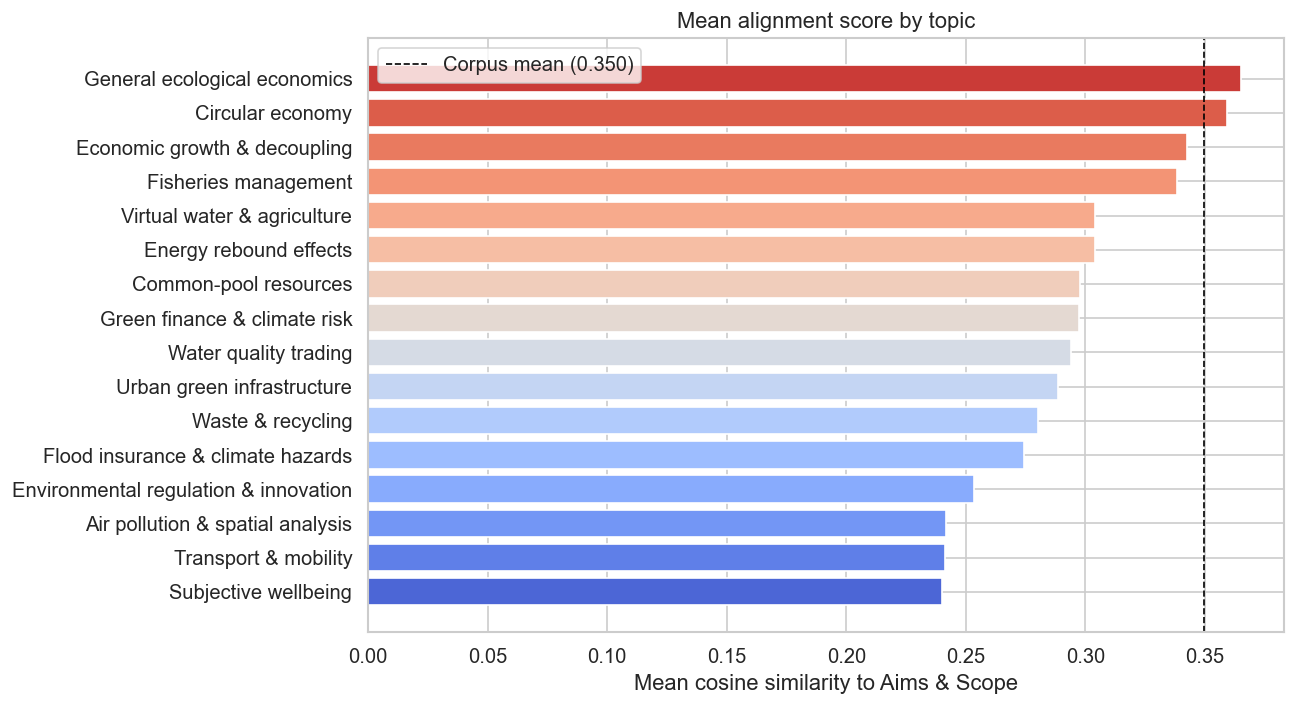

In [24]:
ts = topic_scores.reset_index()
fig, ax = plt.subplots(figsize=(11, max(5, len(ts) * 0.38)))
ax.barh(ts['topic_label'], ts['mean'], color=sns.color_palette('coolwarm_r', len(ts)), edgecolor='white')
ax.axvline(df['alignment_score'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Corpus mean ({df["alignment_score"].mean():.3f})')
ax.set_title('Mean alignment score by topic')
ax.set_xlabel('Mean cosine similarity to Aims & Scope')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/fig_topics_alignment.png', dpi=150)
plt.show()

### 7.2 Topic evolution over time

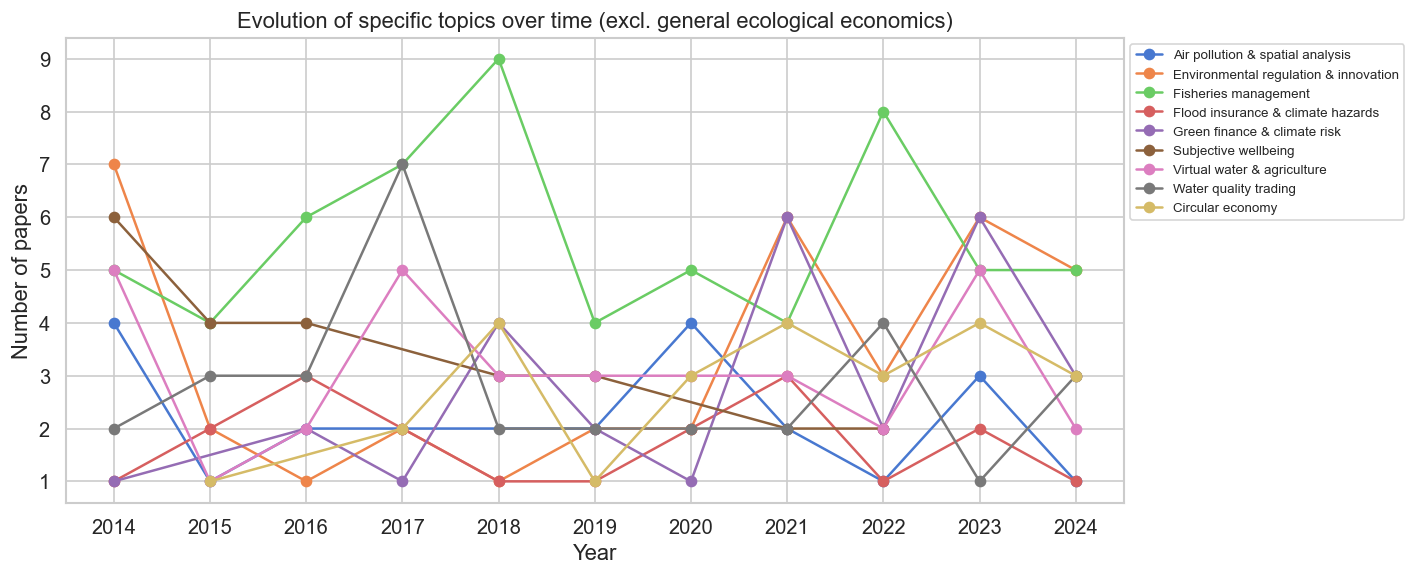

In [42]:
# excluding topic 0 (too dominant) to see the smaller topics clearly
topic_year = (
    df[df['topic'].isin(range(1, 10))]
    .groupby(['year', 'topic_label']).size().reset_index(name='count')
)
fig, ax = plt.subplots(figsize=(12, 5))
for label in topic_year['topic_label'].unique():
    sub = topic_year[topic_year['topic_label'] == label]
    ax.plot(sub['year'], sub['count'], marker='o', label=label, linewidth=1.5)
ax.set_title('Evolution of specific topics over time (excl. general ecological economics)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of papers')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../data/fig_topic_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Qualitative Validation

In [44]:
for label, subset in [('TOP 3 MOST ALIGNED PAPERS', df.nlargest(3, 'alignment_score')),
                       ('BOTTOM 3 LEAST ALIGNED PAPERS (research only)', df_research.nsmallest(3, 'alignment_score'))]:
    print(f'\n{"="*65}\n{label}\n{"="*65}')
    for _, row in subset.iterrows():
        print(f'\nScore: {row["alignment_score"]:.4f}')
        print(f'Title: {row["title"]}')
        print(f'Year: {row["year"]}')
        print(f'Abstract: {row["abstract"][:300]}...')
        print('-' * 65)


TOP 3 MOST ALIGNED PAPERS

Score: 0.7213
Title: Why ecological economics needs to return to its roots: The biophysical foundation of socio-economic systems
Year: 2020
Abstract: Ecological economics was formally established in 1989 with the ambitious vision of developing a new economic paradigm embedding the social and economic systems in the biophysical world. Ecological economics had its roots in the biophysical understanding of economics that pioneers of the field George...
-----------------------------------------------------------------

Score: 0.6842
Title: Between Ostrom and Nordhaus: The research landscape of sustainability economics
Year: 2020
Abstract: We survey the emerging research area of sustainability economics through a quantitative full-text analysis of peer-reviewed journal publications from 1987 to 2013. To identify relevant contributions, we draw on existing definitions of sustainability economics for a keyword-based identification strat...
-------------------------

---
## 9. Export Results

In [45]:
output_cols = ['year', 'title', 'doi', 'date', 'alignment_score', 'is_editorial', 'topic', 'topic_label']
df[output_cols].to_csv('../data/results.csv', index=False)
yearly.to_csv('../data/yearly_drift.csv', index=False)
print('Saved results.csv and yearly_drift.csv')

Saved results.csv and yearly_drift.csv
